# **Boosting Techniques**

#Q1. What is boosting in ML, Explain how it improves weak  learners.

Boosting is an ensemble learning technique in ML that combines multiple weak learners to create strong high accuracy model.

A weak learner is a simple model that has low accuracy, makes systematic errors and performs just better than chance.

Boosting trains weak learners sequentially where : each new model focuses on errors made by previous models. Models are  combined using classification or regression.

#Q2. What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained ?

The main difference between AdaBoost and Gradient Boosting is mainly how each new model is trained to correct previous errors.

AdaBoost - Models are trained sequentially. After each model - misclassified samples get higher weights, correctly classified samples get lower weight. The next weak learner is trained on  this re-weighted dataset. Each model is given a weight alpha based on its accuracy


Gradient Boosting - Here also models are trained sequentially. Instead of re-weighting samples: each new model is trained to predict the resiual errors of the previous models. This is done by minimizing a loss of function using gradient descent. Predictions are updated by adding the new models output to the existing model.


#Q3. How does reguralization help XGBoost?

XGBoost is a powerful boosting algorithm that : can fit training data extremely well, easily overfit, especially with deep trees or many boosting rounds.

Objective = Training Loss + Regularization Term

a. L1 and L2 regularization -
L1 (alpha) - divides some weights to zero
L2 (lambda) - Shrinks leaf weights smoothly

b. Tree Pruning via Regularization -

A split is made only if it reduces loss more than y, weak splits are automaically pruned.

| Parameter          | Purpose                                |
| ------------------ | -------------------------------------- |
| `gamma`            | Minimum loss reduction to make a split |
| `lambda`           | L2 regularization                      |
| `alpha`            | L1 regularization                      |
| `max_depth`        | Limits tree depth                      |
| `min_child_weight` | Controls leaf node size                |
| `learning_rate`    | Shrinks tree contribution              |


#Q4.  Why is CatBoost considered efficient for handling categorical data ?

CatBoost is considered highly effecient in handdling categorical data, as it is designed to work  with categorical data natively. Categorical features have high cardinality, also can lead to overfitting.

It accepts categorical features directly, and no need for manual encoding (one-hot encoding, label-encoding)
CatBoost uses an advanced form of target encoding, but in a safe way.

Problem with traditional target encoding:
Can cause target leakage

Leads to overfitting

CatBoost’s solution:

Uses ordered target statistics

Encodes categories using only past data points during training


#Q5. What are some real-world applications where boosting techniques are preferred over bagging methods?

a. Credit Card and Loan Deault Prediction -
Missclasifying defaulters is costlier than misclassifying safe customers. Boosting focuses more on difficult and minority class -samples. Used algorithm - XGBoost , LightGBM, CatBoost. Predicting whether a customer will default on a loan.

b.Fraud Detection-

Fraud cases are rare and complex, boosting iteratively focuses on miscalssified fraud detections. Ex -- Credit card fraud detection, insuarance claim fraud detection.

c. Customer Churn Prediction -

Churn beaviour is subtle and non linear, boosting captures small behaviour changes over time. Predicting which customers are likely to cancel subscriptionss , targetting high -risk users with retention offers.

#Q6.  Write a Python program to:● Train an AdaBoost Classifier on the Breast Cancer dataset ● Print the model accuracy

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
ada = AdaBoostClassifier(n_estimators = 100, random_state = 42, learning_rate = 0.1)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.956140350877193


#Q7. Write a Python program to:● Train a Gradient Boosting Regressor on the California Housing dataset ● Evaluate performance using R-squared score


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load local CSV
df = pd.read_csv("housing.csv")
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
import pandas as pd

# Reload the DataFrame to ensure 'ocean_proximity' is present
df = pd.read_csv("housing.csv")

# First, handle missing values (e.g., in 'total_bedrooms')
# GradientBoostingRegressor does not handle NaNs by default.
# I will use the median for imputation.
for col in df.select_dtypes(include=['number']).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Convert categorical features to numerical using one-hot encoding
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

print("R2 Score:", r2_score(y_test, model.predict(X_test)))

R2 Score: 0.7616701988665029


#Q8. Write a Python program to:● Train an XGBoost Classifier on the Breast Cancer dataset● Tune the learning rate using GridSearchCV● Print the best parameters and accuracy

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [ ]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Hyperparameter grid for learning rate
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train model
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Results
print("Best Parameters:", grid.best_params_)
print(f"Test Accuracy: {accuracy:.4f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:49:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.2}
Test Accuracy: 0.9561


#Q9.  Write a Python program to: ● Train a CatBoost Classifier ● Plot the confusion matrix using seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00
Accuracy: 0.9736842105263158


<Axes: >

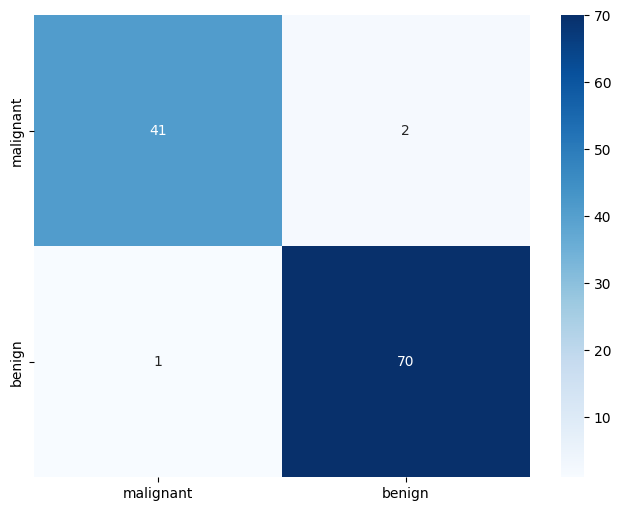

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

!pip install catboost
from catboost import CatBoostClassifier

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test =  train_test_split(X,y, test_size = 0.2, random_state = 42)
model = CatBoostClassifier(
    iterations = 100,
    learning_rate = 0.1,
    depth = 6,
    verbose = False
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot = True, cmap = 'Blues', xticklabels = data.target_names, yticklabels = data.target_names)

#Q10.  You're working for a FinTech company trying to predict loan default usingcustomer demographics and transaction behavior.The dataset is imbalanced, contains missing values, and has both numeric andcategorical features.Describe your step-by-step data science pipeline using boosting techniques:● Data preprocessing & handling missing/categorical values● Choice between AdaBoost, XGBoost, or CatBoost● Hyperparameter tuning strategy● Evaluation metrics you'd choose and why● How the business would benefit from your model




1. Data Pre-processing -

Handling missing values, by using median as it is robust to outliers for numerical values, in case of categorical values, mode can be used, tree based boosting benefit.

Handling categorical features - class weighting , probability threshold tuning, precision-recall optimization

2. Choice of Boosting Algorithm

CatBoost - handles catagorical features natively, robust  to missing values, ordered boosting


3. Hyper Parameter Tuning Strategy - iterations, learning_rate, depth, class_weights, RandomizedSearchCV


4.

| Metric               | Why It Matters                  |
| -------------------- | ------------------------------- |
| **ROC-AUC**          | Overall ranking ability         |
| **Precision**        | Avoid approving risky borrowers |
| **Recall**           | Catch maximum defaulters        |
| **F1-Score**         | Balance between risk & growth   |
| **PR-AUC**           | Best for imbalanced data        |
| **Confusion Matrix** | Business interpretability       |




Business Impact
How the Business Benefits

Reduced loan defaults

Improved approval quality

Risk-based pricing

Faster automated credit decisions

Explainable decisions for regulators